# Per-strain consensus sequences (20260630 pairwise interaction run)

Build a consensus 16S sequence for each strain tested, using the demultiplexed reads.

**Idea.** Each strain is assigned to many wells, each time paired with a *different* partner
(see `setup/strain_layout_20260630.csv`; `strain1`/`strain2` = the two strains in a well).
Within one well the reads are usually dominated by one of the two strains, so a single well is
not reliable. But because a given strain recurs across ~all of its wells while its partners change,
**the sequence that shows up in a majority of that strain's wells is the strain itself.**

**Method.**
1. *Per well* — cluster the reads by identity (greedy, `WITHIN_THR`), keep each cluster with
   `>= MIN_READS` reads and represent it by the cluster **medoid**. A well thus yields 1–2
   representative sequences (its dominant strain(s)).
2. *Per strain* — pool the representatives from every well the strain appears in, cluster them
   across wells (`CROSS_THR`), and pick the cross-cluster that spans the **most distinct wells**.
   If that cluster covers a majority of the strain's *informative* wells (wells that produced any
   reads), it is the strain.
3. *Consensus* — merge that cluster's per-well representatives by **majority vote** at each aligned
   position (reference-anchored, with majority-supported insertions).

Note: ~63% of wells are empty, so coverage is reported against *informative* wells (wells with reads),
which is the meaningful denominator for "a majority of the samples where the strain was present".


In [15]:
import os, glob, time, collections
import numpy as np, pandas as pd
import edlib
from Bio import SeqIO

# ---- paths ----
BASE      = '/home/rl/scripts/karl/pairwise_interaction_experiments/20260721'
LAYOUT    = f'{BASE}/setup/strain_layout_20260721_plate1_2_swapped.csv'
DEMUX_DIR = f'{BASE}/demux/unflipped'
OUT_DIR   = f'{BASE}/analysis/consensus'
os.makedirs(OUT_DIR, exist_ok=True)
plates_used = np.arange(1,20,2)  # only odd-numbered plates were used in this sub experiment

# ---- parameters ----
LEN_LO, LEN_HI = 1350, 1500   # keep reads within full-length 16S window
READ_CAP       = 80           # max reads used per well (speed)
WITHIN_THR     = 0.95         # identity to merge reads of the same strain within a well
MIN_READS      = 4            # min reads for a within-well cluster to count
CROSS_THR      = 0.92         # identity to merge per-well representatives across wells
MEDOID_CAP     = 25           # subsample size when computing a medoid


In [16]:
# ---- helpers ----
def identity(a, b):
    r = edlib.align(a, b, mode='NW', task='distance')
    return 1 - r['editDistance'] / max(len(a), len(b))

def edit_distance(a, b):
    r = edlib.align(a, b, mode='NW', task='distance')
    return r['editDistance']

def load_reads(fq):
    if not os.path.exists(fq) or os.path.getsize(fq) == 0:
        return []
    out = []
    for rec in SeqIO.parse(fq, 'fastq'):
        s = str(rec.seq)
        if LEN_LO <= len(s) <= LEN_HI:
            out.append(s)
            if len(out) >= READ_CAP:
                break
    return out

def greedy_cluster(seqs, thr):
    """Greedy identity clustering. Returns list of [seed_seq, [member_indices]]."""
    cents = []
    for i, s in enumerate(seqs):
        best, bj = -1.0, -1
        for j, (cs, mem) in enumerate(cents):
            v = identity(s, cs)
            if v > best:
                best, bj = v, j
        if best >= thr:
            cents[bj][1].append(i)
        else:
            cents.append([s, [i]])
        # print(len(cents), end=', ')
    return cents

def medoid(seqs):
    """Sequence minimizing total edit distance to the others (subsampled for speed)."""
    if len(seqs) == 1:
        return seqs[0]
    sub = seqs[:MEDOID_CAP]
    best, best_tot = sub[0], None
    for a in sub:
        tot = sum(edlib.align(a, b, mode='NW', task='distance')['editDistance'] for b in sub)
        if best_tot is None or tot < best_tot:
            best_tot, best = tot, a
    return best

def well_representatives(fq):
    """Per-well: cluster reads, return medoid of each cluster with >= MIN_READS reads."""
    reads = load_reads(fq)
    if not reads:
        return []
    reps = []
    for seed, mem in greedy_cluster(reads, WITHIN_THR):
        if len(mem) >= MIN_READS:
            reps.append(medoid([reads[i] for i in mem]))
    return reps

def majority_consensus(members):
    """Majority-vote consensus of sequences, anchored on their medoid (handles indels)."""
    if len(members) == 1:
        return members[0]
    ref = medoid(members)
    col = collections.defaultdict(collections.Counter)   # ref position -> base counts (incl '-')
    ins = collections.defaultdict(list)                  # ref position -> inserted strings
    for m in members:
        r  = edlib.align(m, ref, mode='NW', task='path')
        na = edlib.getNiceAlignment(r, m, ref)
        q, t = na['query_aligned'], na['target_aligned']
        rp, cur = -1, []
        for qc, tc in zip(q, t):
            if tc != '-':                 # a reference position
                if cur:
                    ins[rp].append(''.join(cur)); cur = []
                rp += 1
                col[rp][qc] += 1
            else:                         # insertion relative to reference
                cur.append(qc)
        if cur:
            ins[rp].append(''.join(cur))
    N = len(members)
    out = []
    for p in range(max(col) + 1):
        base, _ = col[p].most_common(1)[0]
        if base != '-':                   # majority says keep this position
            out.append(base)
        seg = ins.get(p, [])              # insertion after position p, if majority-supported
        if len(seg) > N / 2:
            out.append(collections.Counter(seg).most_common(1)[0][0])
    return ''.join(out)


In [17]:
# ---- load layout, map strains -> wells, and each well -> fastq ----
df = pd.read_csv(LAYOUT)
# display(df)
#filter df = df[df['dest_plate'].isin(plates_used)]
df = df[df['dest_plate'].isin(plates_used)]

df['fq'] = df.apply(lambda r: f"{DEMUX_DIR}/Plate{int(r['dest_plate']):02d}_{r['dest_well']}.fastq", axis=1)

strain_wells = collections.defaultdict(list)   # strain -> [fastq paths]
for _, r in df.iterrows():
    for c in ('strain1', 'strain2'):
        s = r[c]
        if isinstance(s, str) and s:
            strain_wells[s].append(r['fq'])

strains = sorted(strain_wells)
sizes = df['fq'].apply(lambda f: os.path.getsize(f) if os.path.exists(f) else -1)
print(f"wells (layout rows)       : {len(df)}")
print(f"  missing files           : {(sizes < 0).sum()}")
print(f"  empty (0 byte) files    : {(sizes == 0).sum()}")
print(f"  non-empty files         : {(sizes > 0).sum()}")
print(f"unique strains            : {len(strains)}")
wc = pd.Series({s: len(w) for s, w in strain_wells.items()})
print(f"wells per strain (min/median/max): {wc.min()} / {int(wc.median())} / {wc.max()}")


wells (layout rows)       : 3080
  missing files           : 0
  empty (0 byte) files    : 2560
  non-empty files         : 520
unique strains            : 87
wells per strain (min/median/max): 56 / 72 / 86


In [18]:
# ---- Phase A: per-well representatives (each unique well processed once, then reused) ----
all_wells = sorted(set(df['fq']))
well_reps = {}
t0 = time.time()
for i, fq in enumerate(all_wells):
    well_reps[fq] = well_representatives(fq)
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{len(all_wells)} wells processed ({time.time()-t0:.0f}s)")
    # if i > 100:
    #     break
n_inf = sum(1 for v in well_reps.values() if v)
print(f"done: {len(all_wells)} wells, {n_inf} informative (>=1 representative), {time.time()-t0:.0f}s")


  1000/3080 wells processed (6s)
  2000/3080 wells processed (6s)
  3000/3080 wells processed (6s)
done: 3080 wells, 254 informative (>=1 representative), 6s


In [19]:
# ---- Phase B: per-strain cross-well consensus ----
rows, consensus_seqs = [], {}
t0 = time.time()
for s in strains:
    wells = strain_wells[s]
    reps = []                                   # (rep_seq, well_index)
    informative = 0
    for wi, fq in enumerate(wells):
        wr = well_reps[fq]
        if wr:
            informative += 1
        for seq in wr:
            reps.append((seq, wi))

    # cluster the per-well representatives across wells
    cc = []
    for seq, wi in reps:
        best, bj = -1.0, -1
        for j, c in enumerate(cc):
            v = identity(seq, c['seed'])
            if v > best:
                best, bj = v, j
        if best >= CROSS_THR:
            cc[bj]['mem'].append((seq, wi))
        else:
            cc.append({'seed': seq, 'mem': [(seq, wi)]})
    for c in cc:
        c['nwells'] = len(set(wi for _, wi in c['mem']))
    cc.sort(key=lambda c: -c['nwells'])

    top_wells = cc[0]['nwells'] if cc else 0
    second    = cc[1]['nwells'] if len(cc) > 1 else 0
    cov = top_wells / informative if informative else 0.0
    is_majority = informative > 0 and top_wells > informative / 2

    cons = ''
    if cc and cc[0]['mem']:
        cons = majority_consensus([m for m, _ in cc[0]['mem']])
        consensus_seqs[s] = cons

    if not informative:
        status = 'no_data'
    elif is_majority:
        status = 'ok' if informative >= 2 else 'ok_single_well'
    else:
        status = 'no_majority'

    rows.append(dict(strain=s, assigned_wells=len(wells), informative_wells=informative,
                     top_cluster_wells=top_wells, coverage=round(cov, 3),
                     second_cluster_wells=second, n_cross_clusters=len(cc),
                     top_cluster_members=len(cc[0]['mem']) if cc else 0,
                     consensus_len=len(cons), status=status))

summary = pd.DataFrame(rows).sort_values('informative_wells', ascending=False).reset_index(drop=True)
print(f"phase B done in {time.time()-t0:.0f}s")
print(summary['status'].value_counts())
summary.head(15)


phase B done in 0s
status
ok             81
no_majority     6
Name: count, dtype: int64


,strain,assigned_wells,informative_wells,top_cluster_wells,coverage,second_cluster_wells,n_cross_clusters,top_cluster_members,consensus_len,status
0,K3,72,11,4,0.364,3,6,4,1421,no_majority
1,K11,71,11,11,1.000,2,3,12,1422,ok
2,A5,67,9,9,1.000,5,4,12,1421,ok
3,G8,72,9,6,0.667,4,5,7,1420,ok
4,D3,81,9,9,1.000,0,1,9,1424,ok
5,B7,74,9,6,0.667,4,4,6,1420,ok
6,K8,72,9,8,0.889,1,5,9,1425,ok
7,N23,70,9,9,1.000,1,4,10,1422,ok
8,P8,84,9,7,0.778,5,4,7,1367,ok
9,P23,72,9,6,0.667,4,4,7,1411,ok


In [20]:
# ---- write outputs: consensus FASTA + summary CSV ----
fasta_path = f'{OUT_DIR}/strain_consensus_20260630.fasta'
csv_path   = f'{OUT_DIR}/strain_consensus_summary_20260630.csv'

with open(fasta_path, 'w') as fh:
    for _, row in summary.iterrows():
        s = row['strain']
        if s in consensus_seqs and row['status'] in ('ok', 'ok_single_well'):
            fh.write(f">{s} informative_wells={row['informative_wells']} "
                     f"support={row['top_cluster_wells']}/{row['informative_wells']} "
                     f"coverage={row['coverage']} status={row['status']}\n")
            fh.write(consensus_seqs[s] + '\n')

summary.to_csv(csv_path, index=False)
n_written = summary['status'].isin(['ok', 'ok_single_well']).sum()
print(f"wrote {n_written} consensus sequences -> {fasta_path}")
print(f"wrote summary ({len(summary)} strains)     -> {csv_path}")
display(summary)



wrote 81 consensus sequences -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/strain_consensus_20260630.fasta
wrote summary (87 strains)     -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/strain_consensus_summary_20260630.csv


,strain,assigned_wells,informative_wells,top_cluster_wells,coverage,second_cluster_wells,n_cross_clusters,top_cluster_members,consensus_len,status
0,K3,72,11,4,0.364,3,6,4,1421,no_majority
1,K11,71,11,11,1.000,2,3,12,1422,ok
2,A5,67,9,9,1.000,5,4,12,1421,ok
3,G8,72,9,6,0.667,4,5,7,1420,ok
4,D3,81,9,9,1.000,0,1,9,1424,ok
...,...,...,...,...,...,...,...,...,...,...
82,D1,63,2,2,1.000,1,2,2,1419,ok
83,C3,72,2,2,1.000,1,2,2,1416,ok
84,F13,74,2,2,1.000,0,1,3,1422,ok
85,M12,75,2,1,0.500,1,2,1,1365,no_majority


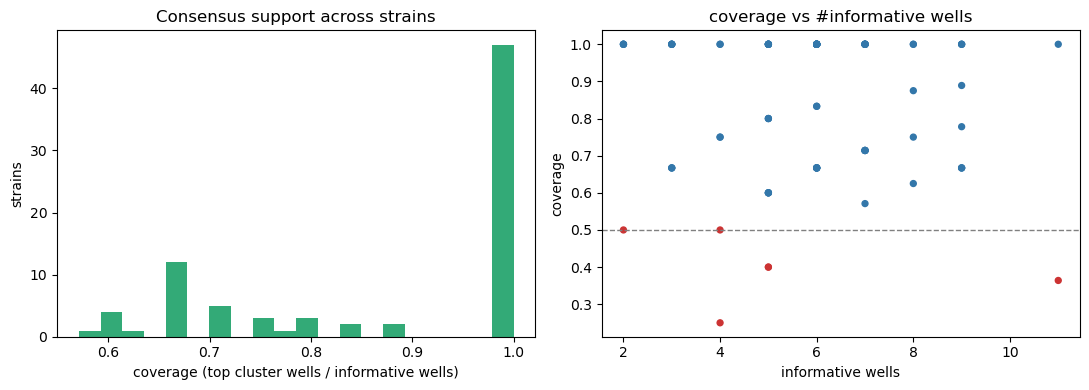

flagged strains (no clear majority / no data):


,strain,assigned_wells,informative_wells,top_cluster_wells,second_cluster_wells,coverage,status
0,K3,72,11,4,3,0.364,no_majority
54,B12,72,5,2,2,0.400,no_majority
67,N13,84,5,2,1,0.400,no_majority
68,F7,56,4,2,1,0.500,no_majority
69,L19,62,4,1,1,0.250,no_majority
85,M12,75,2,1,1,0.500,no_majority


In [21]:
# ---- quick diagnostics ----
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ok = summary[summary['status'].isin(['ok', 'ok_single_well'])]
ax[0].hist(ok['coverage'], bins=20, color='#3a7')
ax[0].set(xlabel='coverage (top cluster wells / informative wells)', ylabel='strains',
          title='Consensus support across strains')
ax[1].scatter(summary['informative_wells'], summary['coverage'], s=18,
              c=(summary['status'] == 'no_majority').map({True: '#c33', False: '#37a'}))
ax[1].set(xlabel='informative wells', ylabel='coverage', title='coverage vs #informative wells')
ax[1].axhline(0.5, ls='--', c='grey', lw=1)
plt.tight_layout(); plt.show()

# strains needing a look
flagged = summary[summary['status'].isin(['no_majority', 'no_data'])]
print("flagged strains (no clear majority / no data):")
flagged[['strain','assigned_wells','informative_wells','top_cluster_wells','second_cluster_wells','coverage','status']]


1422 1365 309 A11 A19
1422 1422 22 A11 A20
1422 1421 210 A11 A5
1422 1434 326 A11 A6
1422 1364 307 A11 B15
1422 1419 214 A11 B24
1422 1411 267 A11 B4
1422 1420 22 A11 B7
1422 1424 31 A11 C11
1422 1422 35 A11 C12
1422 1434 325 A11 C14
1422 1399 394 A11 C15
1422 1401 376 A11 C19
1422 1422 23 A11 C20
1422 1416 208 A11 C3
1422 1422 18 A11 C8
1422 1419 207 A11 D1
1422 1413 264 A11 D11
1422 1411 368 A11 D13
1422 1424 26 A11 D15
1422 1418 208 A11 D20
1422 1424 31 A11 D3
1422 1424 24 A11 D6
1422 1422 19 A11 D7
1422 1422 22 A11 E14
1422 1422 24 A11 E24
1422 1434 325 A11 E3
1422 1422 24 A11 F13
1422 1422 23 A11 F16
1422 1413 264 A11 F17
1422 1424 45 A11 F19
1422 1422 20 A11 F2
1422 1419 208 A11 G17
1422 1419 209 A11 G5
1422 1420 221 A11 G8
1422 1422 31 A11 H20
1422 1419 208 A11 I19
1422 1422 21 A11 J18
1422 1422 32 A11 J2
1422 1424 39 A11 J22
1422 1422 30 A11 J24
1422 1420 32 A11 J5
1422 1423 26 A11 K10
1422 1422 20 A11 K11
1422 1422 28 A11 K15
1422 1422 21 A11 K17
1422 1422 20 A11 K2
1422 1421 

/home/rl/mambaforge/envs/karl_seq_analysis/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/rl/mambaforge/envs/karl_seq_analysis/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/rl/mambaforge/envs/karl_seq_analysis/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


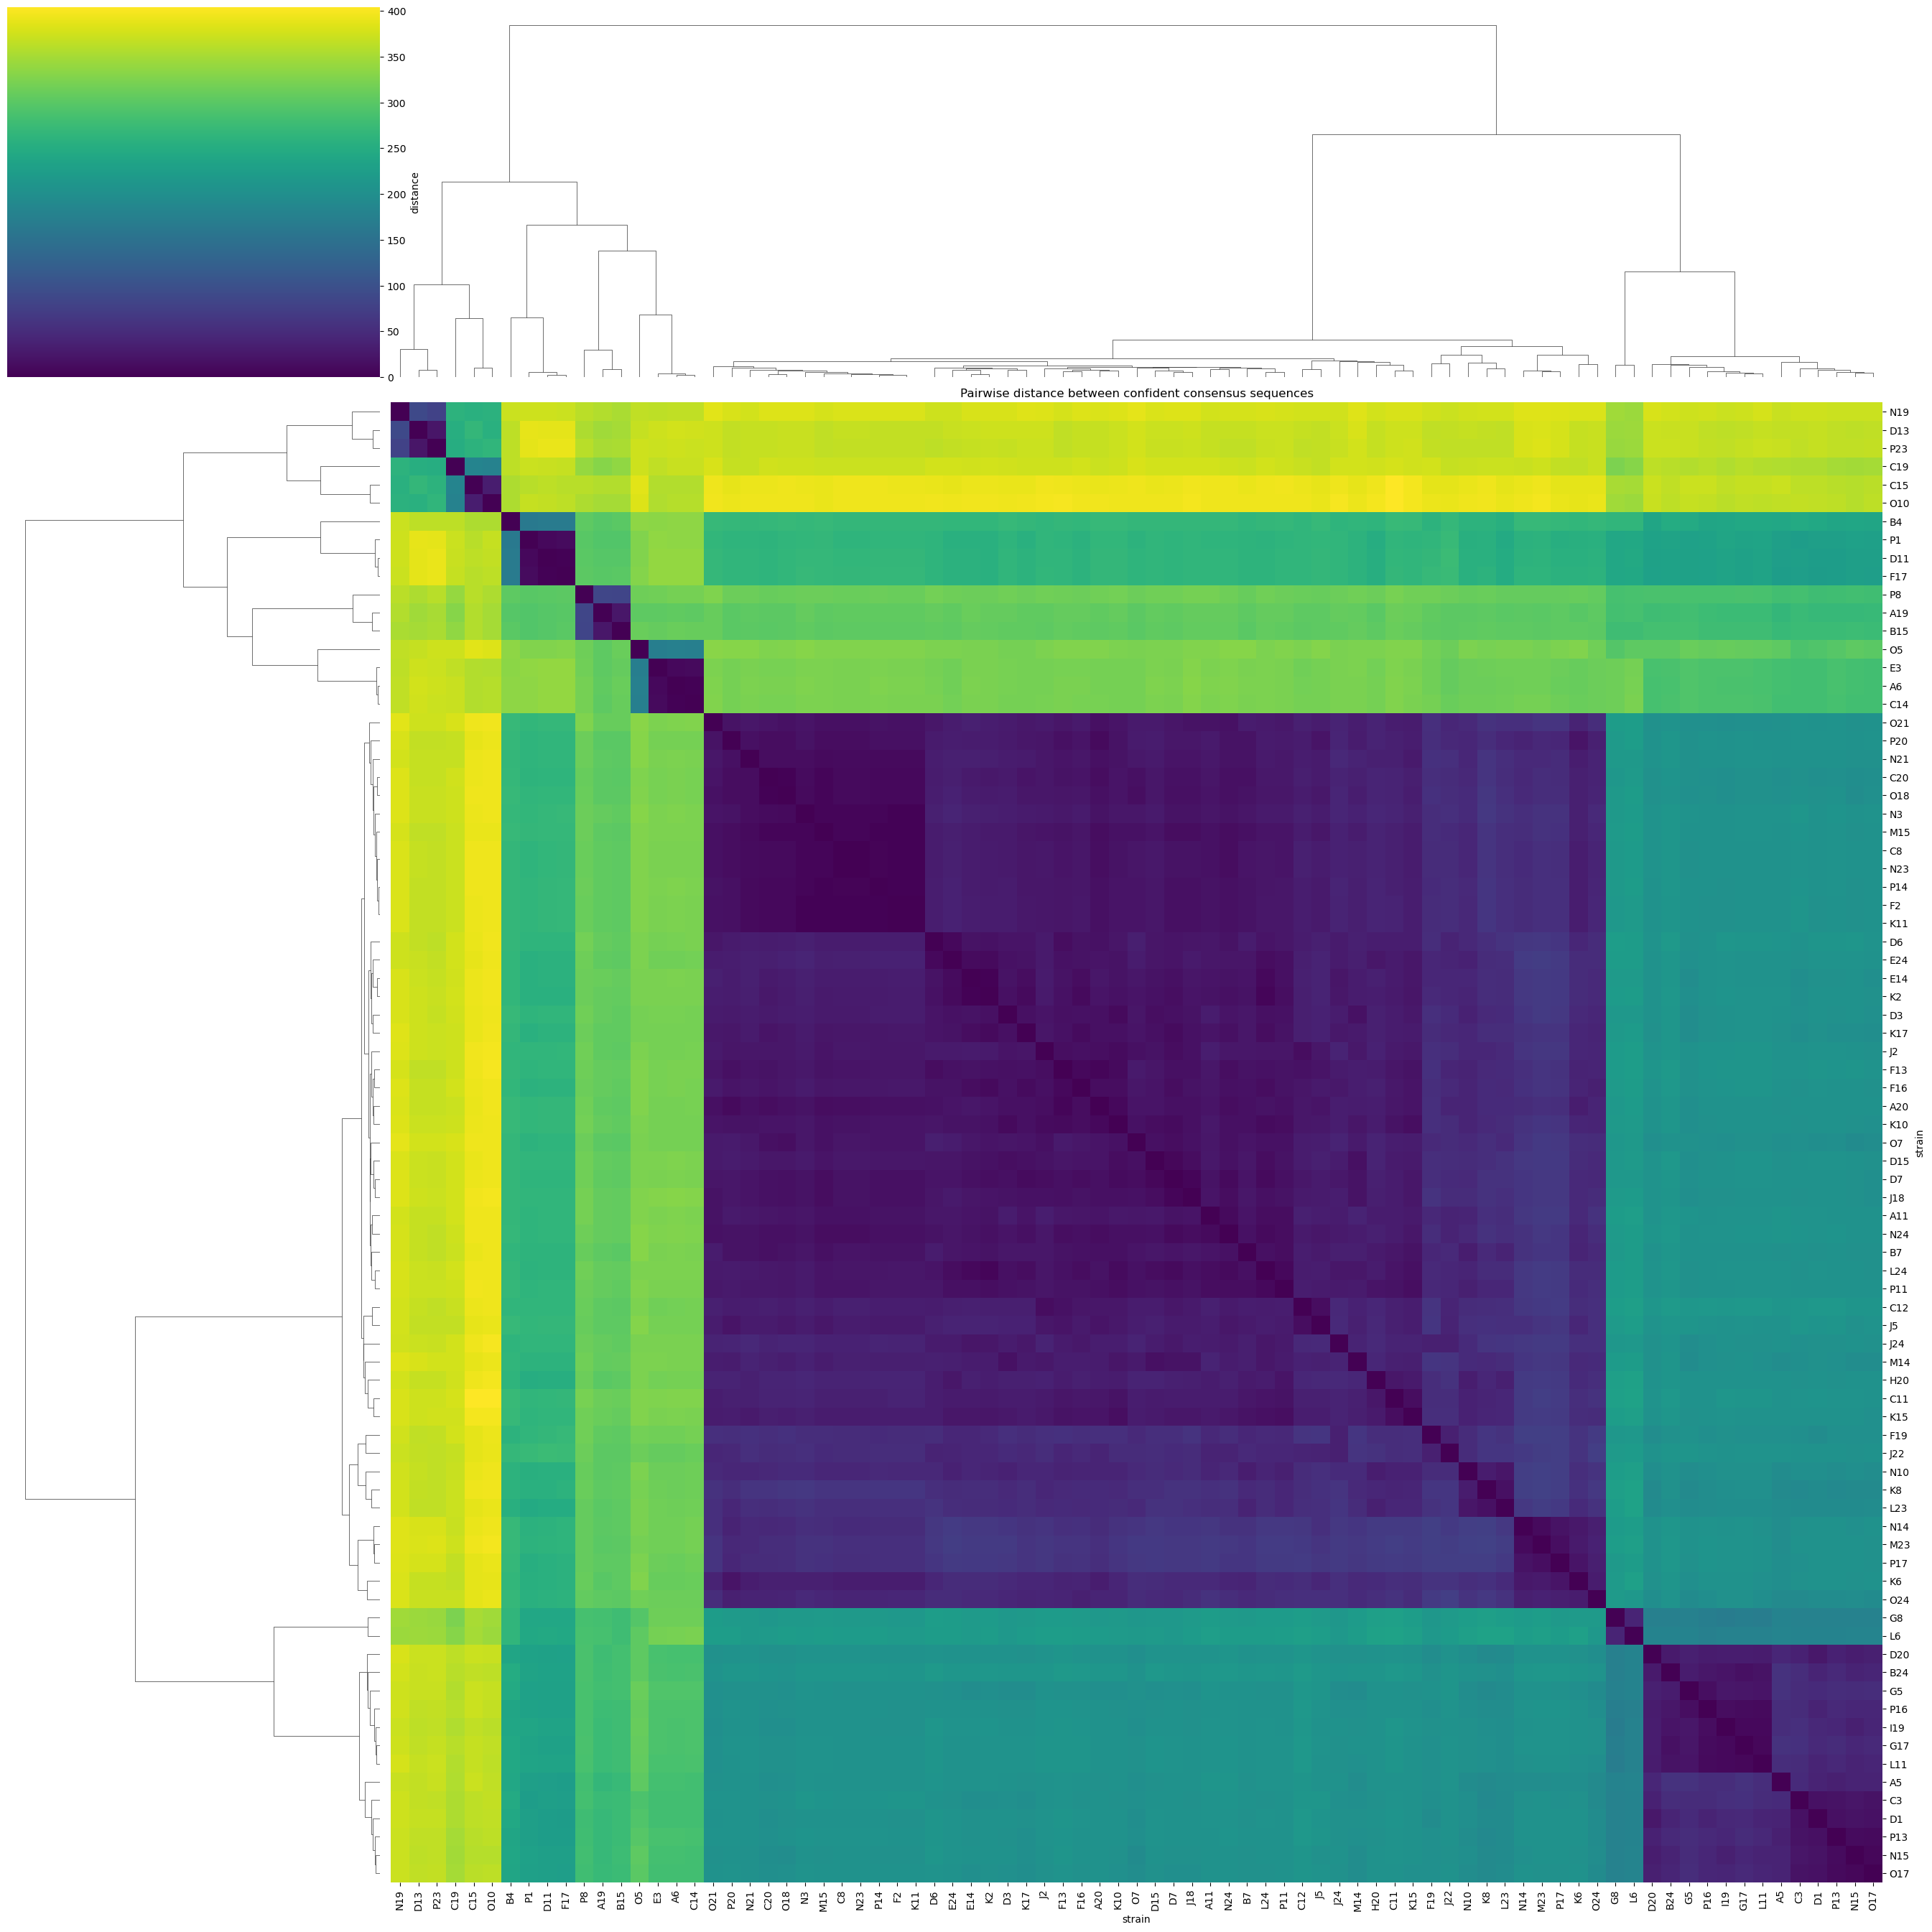

In [22]:
import seaborn as sns

status_map = summary.set_index('strain')['status']
ok_strains = [s for s in strains if s in consensus_seqs and status_map.loc[s] in ('ok', 'ok_single_well')]

if len(ok_strains) > 1:
    seqs = {s: consensus_seqs[s] for s in ok_strains}

    dist_matrix = pd.DataFrame(index=ok_strains, columns=ok_strains, dtype=float)
    for i, a in enumerate(ok_strains):
        dist_matrix.loc[a, a] = 0.0
        for j, b in enumerate(ok_strains):
            if i < j:
                d = edit_distance(seqs[a], seqs[b])
                print(len(seqs[a]), len(seqs[b]), d, a, b)
                dist_matrix.loc[a, b] = d
                dist_matrix.loc[b, a] = d

    #change the following to a clustermap
    # fig, ax = plt.subplots(figsize=(max(6, len(ok_strains) / 3), max(6, len(ok_strains) / 3)))
    g = sns.clustermap(
        dist_matrix,
        cmap='viridis',
        square=True,
        # vmin=0,
        # vmax=1,
        cbar_kws={'label': 'distance'},
        figsize=(max(6, len(ok_strains) / 3), max(6, len(ok_strains) / 3))
    )
    g.ax_heatmap.set_title('Pairwise distance between confident consensus sequences')
    g.ax_heatmap.set_xlabel('strain')
    g.ax_heatmap.set_ylabel('strain')
    # ax.set_title('Pairwise distance between confident consensus sequences')
    # ax.set_xlabel('strain')
    # ax.set_ylabel('strain')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough confident consensus sequences to plot a pairwise distance heatmap.")

## Distinct 16S sequence types

Full-length 16S is highly conserved, so many isolates with different labels can share an identical
sequence. Group the confident consensus sequences into **16S types** (single-linkage at
`TYPE_THR` identity) to see how many genuinely distinct sequences the 100 strains represent.

In [23]:
TYPE_THR = 0.99   # identity to call two consensus sequences the same 16S type

ok_strains = [s for s in strains if s in consensus_seqs and
              summary.set_index('strain').loc[s, 'status'] in ('ok', 'ok_single_well')]

# single-linkage grouping via union-find over >=TYPE_THR identity edges
parent = {s: s for s in ok_strains}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    parent[find(a)] = find(b)

for i in range(len(ok_strains)):
    a = ok_strains[i]
    for j in range(i + 1, len(ok_strains)):
        b = ok_strains[j]
        if identity(consensus_seqs[a], consensus_seqs[b]) >= TYPE_THR:
            union(a, b)

groups = collections.defaultdict(list)
for s in ok_strains:
    groups[find(s)].append(s)
type_list = sorted(groups.values(), key=len, reverse=True)

print(f"{len(ok_strains)} confident consensus sequences collapse into "
      f"{len(type_list)} distinct 16S types (>= {TYPE_THR} identity).\n")
type_rows = []
for k, members in enumerate(type_list, 1):
    rep = max(members, key=lambda s: summary.set_index('strain').loc[s, 'informative_wells'])
    type_rows.append(dict(type_id=f'T{k:02d}', n_strains=len(members),
                          representative=rep, strains=' '.join(sorted(members))))
    if len(members) > 1:
        print(f"  T{k:02d} ({len(members):2d} strains): {' '.join(sorted(members))}")
types_df = pd.DataFrame(type_rows)

# write one representative sequence per 16S type, and a strain->type map
with open(f'{OUT_DIR}/strain_16S_types_20260630.fasta', 'w') as fh:
    for _, row in types_df.iterrows():
        fh.write(f">{row['type_id']} rep={row['representative']} n_strains={row['n_strains']} "
                 f"strains={row['strains'].replace(' ', ',')}\n")
        fh.write(consensus_seqs[row['representative']] + '\n')

strain2type = {s: row['type_id'] for _, row in types_df.iterrows() for s in row['strains'].split()}
type_map = summary.copy()
type_map['type_16S'] = type_map['strain'].map(strain2type).fillna('')
type_map.to_csv(f'{OUT_DIR}/strain_consensus_summary_20260630.csv', index=False)
types_df.to_csv(f'{OUT_DIR}/strain_16S_types_20260630.csv', index=False)
print(f"\nwrote {len(types_df)} representative type sequences and strain->type map to {OUT_DIR}/")
types_df


81 confident consensus sequences collapse into 38 distinct 16S types (>= 0.99 identity).

  T01 (33 strains): A11 A20 B7 C12 C20 C8 D15 D3 D6 D7 E14 E24 F13 F16 F2 J18 J2 J5 K10 K11 K17 K2 L24 M15 N21 N23 N24 N3 O18 O7 P11 P14 P20
  T02 ( 4 strains): G17 I19 L11 P16
  T03 ( 3 strains): A6 C14 E3
  T04 ( 3 strains): D11 F17 P1
  T05 ( 3 strains): N15 O17 P13
  T06 ( 2 strains): C11 K15
  T07 ( 2 strains): M23 N14

wrote 38 representative type sequences and strain->type map to /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/


,type_id,n_strains,representative,strains
0,T01,33,K11,A11 A20 B7 C12 C20 C8 D15 D3 D6 D7 E14 E24 F13...
1,T02,4,I19,G17 I19 L11 P16
2,T03,3,E3,A6 C14 E3
3,T04,3,D11,D11 F17 P1
4,T05,3,P13,N15 O17 P13
5,T06,2,C11,C11 K15
6,T07,2,N14,M23 N14
7,T08,1,A19,A19
8,T09,1,A5,A5
9,T10,1,B15,B15


# compare with previous database

Compared 81 strains against /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db.fasta


,strain,edit_distance,len_current,len_db
4,A6,82,1434,1512
14,C20,88,1422,1500
33,G17,89,1419,1497
2,A20,95,1422,1502
28,F13,95,1422,1500
15,C3,97,1416,1497
61,N21,97,1420,1500
38,J18,98,1422,1502
73,P11,98,1422,1502
22,D3,109,1424,1500


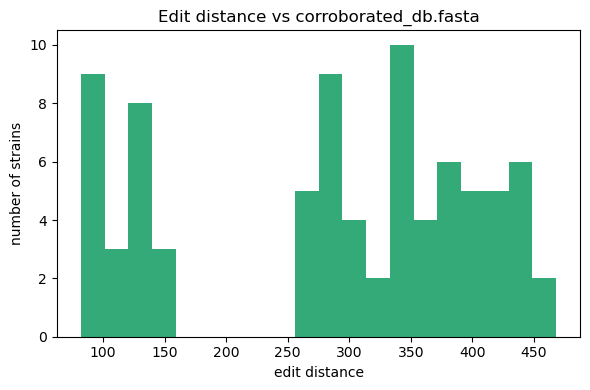

In [24]:
import os
import re

import matplotlib.pyplot as plt

db_path = '/home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db.fasta'

if not os.path.exists(db_path):
    raise FileNotFoundError(f"Could not find database FASTA: {db_path}")

# Parse the other database and map strain names to sequences
db_sequences = {}
for rec in SeqIO.parse(db_path, 'fasta'):
    header = rec.description if rec.description else rec.id
    candidates = [rec.id, rec.name, header.split()[0]]
    matched = False

    for cand in candidates:
        if cand in ok_strains:
            db_sequences[cand] = str(rec.seq)
            matched = True
            break

    if not matched:
        # fallback: try any token in the header that matches a known strain name
        for tok in re.findall(r'[A-Za-z0-9]+', header):
            if tok in ok_strains:
                db_sequences[tok] = str(rec.seq)
                matched = True
                break

# Compare only strains present in both databases
relevant_strains = [s for s in ok_strains if s in db_sequences]
rows = []

for s in relevant_strains:
    d = edit_distance(consensus_seqs[s], db_sequences[s])
    rows.append({
        'strain': s,
        'edit_distance': d,
        'len_current': len(consensus_seqs[s]),
        'len_db': len(db_sequences[s]),
    })

dist_df = pd.DataFrame(rows).sort_values('edit_distance')

print(f"Compared {len(dist_df)} strains against {db_path}")
display(dist_df.head(20))

if len(dist_df) > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(dist_df['edit_distance'], bins=min(20, max(5, len(dist_df) // 2)), color='#3a7')
    ax.set_xlabel('edit distance')
    ax.set_ylabel('number of strains')
    ax.set_title('Edit distance vs corroborated_db.fasta')
    plt.tight_layout()
    plt.show()
else:
    print("No matching strains were found in the corroborated database FASTA.")

Compared 81 strains against /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db.fasta


,strain,edit_distance_full,edit_distance_trimmed,len_current,len_db
4,A6,82,4,1434,1512
14,C20,88,10,1422,1500
33,G17,89,11,1419,1497
2,A20,95,17,1422,1502
28,F13,95,17,1422,1500
...,...,...,...,...,...
67,O18,425,361,1422,1490
24,D7,428,364,1422,1490
21,D20,426,369,1418,1477
65,O10,468,378,1399,1502


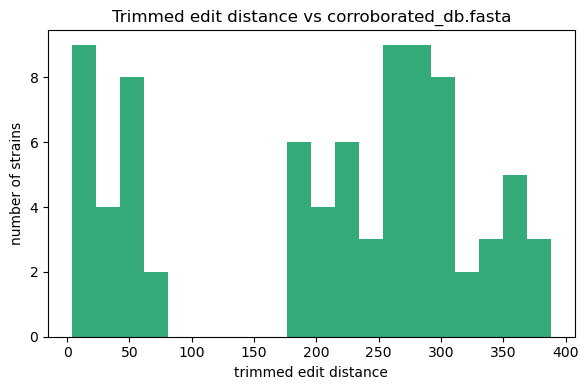

In [25]:
import os
import re
import pandas as pd
from Bio import SeqIO
import edlib

import matplotlib.pyplot as plt

def trimmed_edit_distance(a, b):
    """Edit distance while ignoring prefix/suffix edits (e.g. overhangs)."""
    if not a and not b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    r = edlib.align(a, b, mode='NW', task='path')
    na = edlib.getNiceAlignment(r, a, b)
    q_aln = na['query_aligned']
    t_aln = na['target_aligned']

    # Keep only the alignment span between the first and last exact matches.
    match_idx = [
        i for i, (qc, tc) in enumerate(zip(q_aln, t_aln))
        if qc != '-' and tc != '-' and qc == tc
    ]

    if not match_idx:
        # Fall back to the full alignment distance if there is no shared interior.
        return r['editDistance']
    
    #look for the first block that has at least 5 consecutive matches, and the last block that has at least 5s consecutive matches
    first_block_start, last_block_end = None, None
    consecutive_matches = 0
    #loop for finding first block
    for i in range(len(match_idx)):
        if i == 0 or match_idx[i] == match_idx[i - 1] + 1:
            consecutive_matches += 1
        else:
            consecutive_matches = 1

        if consecutive_matches >= 5 and first_block_start is None:
            first_block_start = match_idx[i - 2]  # start of the block
            break
    
    #loop for finding last block
    consecutive_matches = 0
    for i in range(len(match_idx) - 1, -1, -1):
        if i == len(match_idx) - 1 or match_idx[i] == match_idx[i + 1] - 1:
            consecutive_matches += 1
        else:
            consecutive_matches = 1

        if consecutive_matches >= 5 and last_block_end is None:
            last_block_end = match_idx[i + 2]  # end of the block
            break
    
    if first_block_start is None or last_block_end is None or first_block_start >= last_block_end:
        # Fall back to the full alignment distance if there is no valid interior block.
        return r['editDistance']
    

    # start, end = match_idx[0], match_idx[-1]
    start, end = first_block_start, last_block_end
    dist = 0
    for qc, tc in zip(q_aln[start:end + 1], t_aln[start:end + 1]):
        if qc == tc:
            continue
        dist += 1  # mismatch or gap -> one edit
    return dist

db_path = '/home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db.fasta'

if not os.path.exists(db_path):
    raise FileNotFoundError(f"Could not find database FASTA: {db_path}")

# Parse the other database and map strain names to sequences
db_sequences = {}
for rec in SeqIO.parse(db_path, 'fasta'):
    header = rec.description if rec.description else rec.id
    candidates = [rec.id, rec.name, header.split()[0]]
    matched = False

    for cand in candidates:
        if cand in ok_strains:
            db_sequences[cand] = str(rec.seq)
            matched = True
            break

    if not matched:
        # fallback: try any token in the header that matches a known strain name
        for tok in re.findall(r'[A-Za-z0-9]+', header):
            if tok in ok_strains:
                db_sequences[tok] = str(rec.seq)
                matched = True
                break

# Compare only strains present in both databases
relevant_strains = [s for s in ok_strains if s in db_sequences]
rows = []

for s in relevant_strains:
    full_d = edit_distance(consensus_seqs[s], db_sequences[s])
    trim_d = trimmed_edit_distance(consensus_seqs[s], db_sequences[s])
    rows.append({
        'strain': s,
        'edit_distance_full': full_d,
        'edit_distance_trimmed': trim_d,
        'len_current': len(consensus_seqs[s]),
        'len_db': len(db_sequences[s]),
    })
    #save alignment to a new fasta file for debugging
    alignments_file = f'./alignments/alignment_debug_{s}.fasta'
    os.makedirs(os.path.dirname(alignments_file), exist_ok=True)
    with open(alignments_file, 'w') as fh:
        #get alignment for the full sequences
        r = edlib.align(consensus_seqs[s], db_sequences[s], mode='NW', task='path')
        na = edlib.getNiceAlignment(r, consensus_seqs[s], db_sequences[s])
        q_aln = na['query_aligned']
        t_aln = na['target_aligned']
        fh.write(f">query\n{q_aln}\n")
        fh.write(f">target\n{t_aln}\n")

dist_df = pd.DataFrame(rows).sort_values('edit_distance_trimmed')

print(f"Compared {len(dist_df)} strains against {db_path}")
display(dist_df)

if len(dist_df) > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(
        dist_df['edit_distance_trimmed'],
        bins=min(20, max(5, len(dist_df) // 2)),
        color='#3a7'
    )
    ax.set_xlabel('trimmed edit distance')
    ax.set_ylabel('number of strains')
    ax.set_title('Trimmed edit distance vs corroborated_db.fasta')
    plt.tight_layout()
    plt.show()
else:
    print("No matching strains were found in the corroborated database FASTA.")

now do the same but compare against all sequences for the strain in merge_consensus_sequences/collapse_naive_updated3_15diff/merged_naive_db.fasta which contains multiple sequences for each strain in many case (this can be determined by splitting the sequence header by '_' -- the characters before the split are the sequence name, the characters after the split are referring to the experiment that yielded that sequence)

In [26]:
from collections import defaultdict

# compare against merged_naive_db.fasta (multiple sequences per strain; header format: <strain>_<experiment>)

db_path = '/home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/merged_naive_db.fasta'
if not os.path.exists(db_path):
    raise FileNotFoundError(f"Could not find database FASTA: {db_path}")

# collect all DB sequences per strain (strain token = header.split('_')[0])
db_entries = defaultdict(list)
for rec in SeqIO.parse(db_path, 'fasta'):
    header = rec.description if rec.description else rec.id
    strain_tok = header.split('_')[0]
    if strain_tok in ok_strains:
        db_entries[strain_tok].append((header, str(rec.seq)))

relevant_strains = sorted(s for s in ok_strains if s in db_entries)
rows = []
os.makedirs('./alignments_multi', exist_ok=True)

for s in relevant_strains:
    best = None
    for idx, (hdr, dbseq) in enumerate(db_entries[s]):
        full_d = edit_distance(consensus_seqs[s], dbseq)
        trim_d = trimmed_edit_distance(consensus_seqs[s], dbseq)
        if best is None or trim_d < best['trim_d']:
            best = dict(trim_d=trim_d, full_d=full_d, hdr=hdr, dbseq_len=len(dbseq), idx=idx, dbseq=dbseq)
    # save best alignment for debugging
    aln_path = f'./alignments_multi/alignment_best_{s}.fasta'
    r = edlib.align(consensus_seqs[s], best['dbseq'], mode='NW', task='path')
    na = edlib.getNiceAlignment(r, consensus_seqs[s], best['dbseq'])
    with open(aln_path, 'w') as fh:
        fh.write(f">query_{s}\n{na['query_aligned']}\n")
        fh.write(f">target_{best['hdr']}\n{na['target_aligned']}\n")

    rows.append({
        'strain': s,
        'n_db_seqs': len(db_entries[s]),
        'best_db_header': best['hdr'],
        'edit_distance_full': best['full_d'],
        'edit_distance_trimmed': best['trim_d'],
        'len_current': len(consensus_seqs[s]),
        'len_db_best': best['dbseq_len'],
        'alignment_path': aln_path
    })

dist_df_multi = pd.DataFrame(rows).sort_values('edit_distance_trimmed').reset_index(drop=True)
print(f"Compared {len(dist_df_multi)} strains against {db_path} (best match per strain).")
display(dist_df_multi)

Compared 81 strains against /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/merged_naive_db.fasta (best match per strain).


,strain,n_db_seqs,best_db_header,edit_distance_full,edit_distance_trimmed,len_current,len_db_best,alignment_path
0,A6,2,A6_0808s,204,1,1434,1636,./alignments_multi/alignment_best_A6.fasta
1,G17,3,G17_1204s,202,5,1419,1614,./alignments_multi/alignment_best_G17.fasta
2,C20,3,C20_0808s,199,9,1422,1612,./alignments_multi/alignment_best_C20.fasta
3,N21,2,N21_0808s,206,11,1420,1617,./alignments_multi/alignment_best_N21.fasta
4,K10,3,K10_0415m,202,12,1423,1610,./alignments_multi/alignment_best_K10.fasta
...,...,...,...,...,...,...,...,...
76,D1,2,D1_1204s,419,356,1419,1559,./alignments_multi/alignment_best_D1.fasta
77,N24,3,N24_1204s,520,363,1421,1585,./alignments_multi/alignment_best_N24.fasta
78,C14,2,C14_0808s,456,368,1434,1602,./alignments_multi/alignment_best_C14.fasta
79,O18,2,O18_0808s,513,377,1422,1601,./alignments_multi/alignment_best_O18.fasta


In [27]:
dist_df_multi.to_csv(f'{OUT_DIR}/strain_consensus_vs_merged_naive_db_20260630.csv', index=False)